In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# ── Experiment config ─────────────────────────────────────────────────────────
RATIOS   = [25, 50, 75, 100]

# Select subsampling strategy:
#   'eigenvector' — top-K% by global cumulative degree (hub-biased, flat curve)
#   'random'      — nested random K% (unbiased, expected decreasing curve)
STRATEGY = 'random'

def train_dir(ratio):
    if ratio == 100:
        return "3ed_trai_h_graphs_hetero_graphs"   # shared by both strategies
    suffix = "rand" if STRATEGY == 'random' else "sub"
    return f"3ed_trai_h_graphs_hetero_{suffix}{ratio}"

TEST_DIR = "3ed_tes_h_graphs_hetero_graphs"
print(f"Strategy: {STRATEGY}")


Running on: cpu
Strategy: random


In [6]:
from torch_geometric.nn import HeteroConv, GCNConv
from torch_geometric.utils import negative_sampling


class HeteroGAE(nn.Module):
    """
    Graph Autoencoder — paper architecture.

    Encoder : 2-layer HeteroConv GCN.
              Input  : community_id_norm (1-D, from LPA)
              Output : node embeddings Z ∈ R^(N × out_channels)

    Decoder : temperature-scaled normalised inner product
              P(edge u→v is normal) = σ(t · ẑ_u · ẑ_v)

              L2 normalisation keeps the inner product in [-1, 1].
              Temperature t=4 stretches it to [-4, 4] before sigmoid,
              so the model can express strong confidence and gradients
              are much larger → faster convergence in fewer epochs.

    Training (benign-only graphs):
        positive = existing edges   → target 1
        negative = random non-edges → target 0
        loss = BCE(σ(t·pos), 1) + BCE(σ(t·neg), 0)

    Anomaly score: 1 − σ(t · ẑ_u · ẑ_v)
        Near 1 = model never learned this connection → anomalous.
    """
    def __init__(self, hidden_channels=64, out_channels=32, temperature=4.0):
        super().__init__()
        self.temperature = temperature

        self.conv1 = HeteroConv({
            ('ip', 'network',   'ip'): GCNConv(-1, hidden_channels),
            ('ip', 'context',   'ip'): GCNConv(-1, hidden_channels),
            ('ip', 'knowledge', 'ip'): GCNConv(-1, hidden_channels),
        }, aggr='sum')

        self.norm = nn.LayerNorm(hidden_channels)

        self.conv2 = HeteroConv({
            ('ip', 'network',   'ip'): GCNConv(-1, out_channels),
            ('ip', 'context',   'ip'): GCNConv(-1, out_channels),
            ('ip', 'knowledge', 'ip'): GCNConv(-1, out_channels),
        }, aggr='sum')

    def encode(self, data):
        x = self.conv1(data.x_dict, data.edge_index_dict)['ip']
        x = self.norm(x)
        x = F.relu(x)
        return self.conv2({'ip': x}, data.edge_index_dict)['ip']

    def decode(self, z, edge_index):
        """σ(t · ẑ_src · ẑ_dst) — temperature-scaled normalised inner product."""
        z_n = F.normalize(z, p=2, dim=1)
        src, dst = edge_index
        return torch.sigmoid(self.temperature * (z_n[src] * z_n[dst]).sum(dim=1))


In [ ]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
)


def load_single_graph(directory, filename):
    data = torch.load(os.path.join(directory, filename), weights_only=False)
    if not data.edge_types:
        return None
    data['ip'].x = data['ip'].x[:, :1]   # community_id_norm only (paper)
    return data


def load_graphs(directory):
    files  = sorted(f for f in os.listdir(directory) if f.endswith('.pt'))
    graphs = [load_single_graph(directory, f) for f in files]
    return [g for g in graphs if g is not None]


def train_gae(model, graphs, epochs=50, device='cpu'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for data in graphs:
            if not data.edge_types:
                continue
            data = data.to(device)
            optimizer.zero_grad()
            z         = model.encode(data)
            num_nodes = data['ip'].num_nodes
            loss      = torch.tensor(0.0, device=device)
            for et in data.edge_types:
                ei = data[et].edge_index
                if num_nodes < 2 or ei.shape[1] == 0:
                    continue
                pos_scores = model.decode(z, ei)
                loss = loss + F.binary_cross_entropy(pos_scores, torch.ones_like(pos_scores))
                neg_ei = negative_sampling(ei, num_nodes=num_nodes,
                                           num_neg_samples=ei.shape[1], method='sparse')
                neg_scores = model.decode(z, neg_ei)
                loss = loss + F.binary_cross_entropy(neg_scores, torch.zeros_like(neg_scores))
            if loss.item() > 0:
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs}  loss={total_loss/len(graphs):.4f}")


@torch.no_grad()
def evaluate_anomaly_detection(model, test_graphs, device='cpu', label=""):
    """
    Metrics computed at the threshold that maximises balanced accuracy
    (equal weight to TPR and TNR — robust to class imbalance).

    Reported metrics
    ─────────────────────────────────────────────────────────────
    ROC-AUC          ranking quality (attack vs benign)
    PR-AUC           precision-recall summary (attack-class focus)
    Accuracy         TP+TN / total  — inflated by imbalance (shown for reference)
    Balanced Acc     (TPR + TNR) / 2  — imbalance-robust accuracy
    MCC              Matthews Correlation Coefficient ∈ [-1,1]
                     0 = random, 1 = perfect; best single metric for imbalance
    TPR@FPR=1%       detection rate allowing 1% false alarm rate (operational)
    ─────────────────────────────────────────────────────────────
    """
    model.eval()
    model.to(device)
    all_scores, all_labels = [], []
    per_graph_aucs = []

    for data in test_graphs:
        if not data.edge_types:
            continue
        data = data.to(device)
        z = model.encode(data)

        g_scores, g_labels = [], []
        for et in data.edge_types:
            if 'edge_label' not in data[et]:
                continue
            ei = data[et].edge_index
            scores = (1.0 - model.decode(z, ei)).cpu().tolist()
            g_scores.extend(scores)
            g_labels.extend(data[et].edge_label.cpu().tolist())

        if g_scores:
            lo, hi = min(g_scores), max(g_scores)
            if hi > lo:
                g_scores = [(s - lo) / (hi - lo) for s in g_scores]

        all_scores.extend(g_scores)
        all_labels.extend(g_labels)

        if len(set(g_labels)) == 2:
            try:
                g_auc = roc_auc_score(g_labels, g_scores)
                per_graph_aucs.append(max(g_auc, 1.0 - g_auc))
            except Exception:
                pass

    n_benign = all_labels.count(0)
    n_attack = all_labels.count(1)
    print(f"  Test — benign: {n_benign:,}  attack: {n_attack:,}")

    if n_attack == 0 or n_benign == 0:
        print("  WARNING: only one class present — metrics unavailable")
        return {"auc": 0.5, "pr_auc": 0.0, "accuracy": 0.0, "balanced_acc": 0.5,
                "mcc": 0.0, "tpr_at_1fpr": 0.0, "per_graph_aucs": [],
                "fpr_curve": [], "tpr_curve": [], "precision_curve": [], "recall_curve": []}

    auc = roc_auc_score(all_labels, all_scores)
    if auc < 0.5:
        auc    = 1.0 - auc
        scores = [-s for s in all_scores]
    else:
        scores = all_scores

    labels_arr = np.array(all_labels)
    scores_arr = np.array(scores)

    fpr, tpr, roc_thresholds = roc_curve(labels_arr, scores_arr)
    pr_auc                   = average_precision_score(labels_arr, scores_arr)
    tpr_at_1fpr              = float(np.interp(0.01, fpr, tpr))

    # ── Find threshold maximising balanced accuracy ───────────────────────────
    # balanced_acc = (TPR + TNR) / 2  at each ROC point
    balanced_at_thresh = (tpr + (1 - fpr)) / 2
    best_roc_idx  = int(np.argmax(balanced_at_thresh))
    best_threshold = float(roc_thresholds[best_roc_idx])

    preds = (scores_arr >= best_threshold).astype(int)
    accuracy     = float(accuracy_score(labels_arr, preds))
    balanced_acc = float(balanced_accuracy_score(labels_arr, preds))
    mcc          = float(matthews_corrcoef(labels_arr, preds))

    # Confusion matrix values at best threshold
    tp = int(((preds == 1) & (labels_arr == 1)).sum())
    fp = int(((preds == 1) & (labels_arr == 0)).sum())
    tn = int(((preds == 0) & (labels_arr == 0)).sum())
    fn = int(((preds == 0) & (labels_arr == 1)).sum())

    precisions, recalls, _ = precision_recall_curve(labels_arr, scores_arr)

    print(f"  ROC-AUC:       {auc:.4f}")
    print(f"  PR-AUC:        {pr_auc:.4f}")
    print(f"  Accuracy:      {accuracy:.4f}  ← misleading (imbalanced; "
          f"{n_benign/(n_benign+n_attack)*100:.1f}% is benign)")
    print(f"  Balanced Acc:  {balanced_acc:.4f}  = (TPR+TNR)/2")
    print(f"  MCC:           {mcc:.4f}  ← headline metric")
    print(f"  TPR@FPR=1%%:   {tpr_at_1fpr:.4f}")
    print(f"  @ threshold={best_threshold:.3f}: "
          f"TP={tp} FP={fp} TN={tn} FN={fn}")
    if per_graph_aucs:
        print(f"  Per-graph AUC: mean={np.mean(per_graph_aucs):.4f}  "
              f"std={np.std(per_graph_aucs):.4f}  "
              f"({len(per_graph_aucs)} graphs with both classes)")

    return {
        "auc":          auc,
        "pr_auc":       pr_auc,
        "accuracy":     accuracy,
        "balanced_acc": balanced_acc,
        "mcc":          mcc,
        "tpr_at_1fpr":  tpr_at_1fpr,
        "per_graph_aucs":  per_graph_aucs,
        "fpr_curve":       fpr.tolist(),
        "tpr_curve":       tpr.tolist(),
        "precision_curve": precisions.tolist(),
        "recall_curve":    recalls.tolist(),
    }


In [ ]:
results = []

print(f"Loading test graphs from '{TEST_DIR}' …")
test_graphs = load_graphs(TEST_DIR)
print(f"  {len(test_graphs)} test graph(s) loaded.\n")

for ratio in RATIOS:
    td    = train_dir(ratio)
    label = f"{ratio}%" if ratio < 100 else "100% (no subsampling)"
    print(f"{'='*55}")
    print(f"Ratio: {label}  |  train dir: {td}")
    print(f"{'='*55}")

    train_graphs = load_graphs(td)
    print(f"  {len(train_graphs)} training graph(s) loaded.")

    model = HeteroGAE(hidden_channels=64, out_channels=32).to(device)
    train_gae(model, train_graphs, epochs=50, device=device)
    metrics = evaluate_anomaly_detection(model, test_graphs, device=device, label=label)
    results.append(metrics)
    print(f"  → AUC={metrics['auc']:.4f}  "
          f"Bal.Acc={metrics['balanced_acc']:.4f}  "
          f"MCC={metrics['mcc']:.4f}  "
          f"TPR@1%%FPR={metrics['tpr_at_1fpr']:.4f}\n")

print("Experiment complete.\n")
print(f"{'Ratio':>6}  {'AUC':>7}  {'Bal.Acc':>8}  {'MCC':>7}  {'Accuracy':>9}  {'TPR@1%FPR':>10}")
print("-" * 58)
for ratio, m in zip(RATIOS, results):
    print(f"{ratio:>5}%  {m['auc']:>7.4f}  {m['balanced_acc']:>8.4f}  "
          f"{m['mcc']:>7.4f}  {m['accuracy']:>9.4f}  {m['tpr_at_1fpr']:>10.4f}")


In [ ]:
# ── Figure 1: Key metrics vs subsampling ratio ────────────────────────────────
METRIC_KEYS    = ["auc", "balanced_acc", "mcc", "tpr_at_1fpr"]
METRIC_LABELS  = ["ROC-AUC", "Balanced Accuracy", "MCC", "TPR @ FPR=1%"]
COLORS         = ["steelblue", "darkorange", "seagreen", "crimson"]

fig, ax = plt.subplots(figsize=(10, 5))

for key, lbl, color in zip(METRIC_KEYS, METRIC_LABELS, COLORS):
    vals = [m[key] for m in results]
    ax.plot(RATIOS, vals, marker='o', linewidth=2, color=color, label=lbl)
    ax.axhline(vals[-1], color=color, linestyle=':', linewidth=0.8, alpha=0.4)

strategy_label = "Random" if STRATEGY == "random" else "Eigenvector-Centrality"
ax.set_title(f"Detection metrics vs. {strategy_label} Subsampling Ratio\n"
             "(train on subsampled benign graphs, test on full graph)", fontsize=13)
ax.set_xlabel("Training graph kept (%)", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_xticks(RATIOS)
ax.set_xticklabels([f"{r}%" for r in RATIOS])
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("metrics_vs_subsampling.png", dpi=150)
plt.show()

# ── Also show plain accuracy to illustrate why it's misleading ───────────────
fig, ax = plt.subplots(figsize=(8, 4))
acc_vals  = [m['accuracy']     for m in results]
bacc_vals = [m['balanced_acc'] for m in results]
ax.plot(RATIOS, acc_vals,  marker='s', color='gray',       label='Accuracy (misleading)')
ax.plot(RATIOS, bacc_vals, marker='o', color='darkorange',  label='Balanced Accuracy')
ax.set_xlabel("Training graph kept (%)", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Accuracy vs Balanced Accuracy\n"
             f"(benign rate = {results[0].get('accuracy', 0):.1%} → plain accuracy is trivially high)",
             fontsize=12)
ax.set_xticks(RATIOS)
ax.set_xticklabels([f"{r}%" for r in RATIOS])
ax.set_ylim(0.85, 1.01)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()


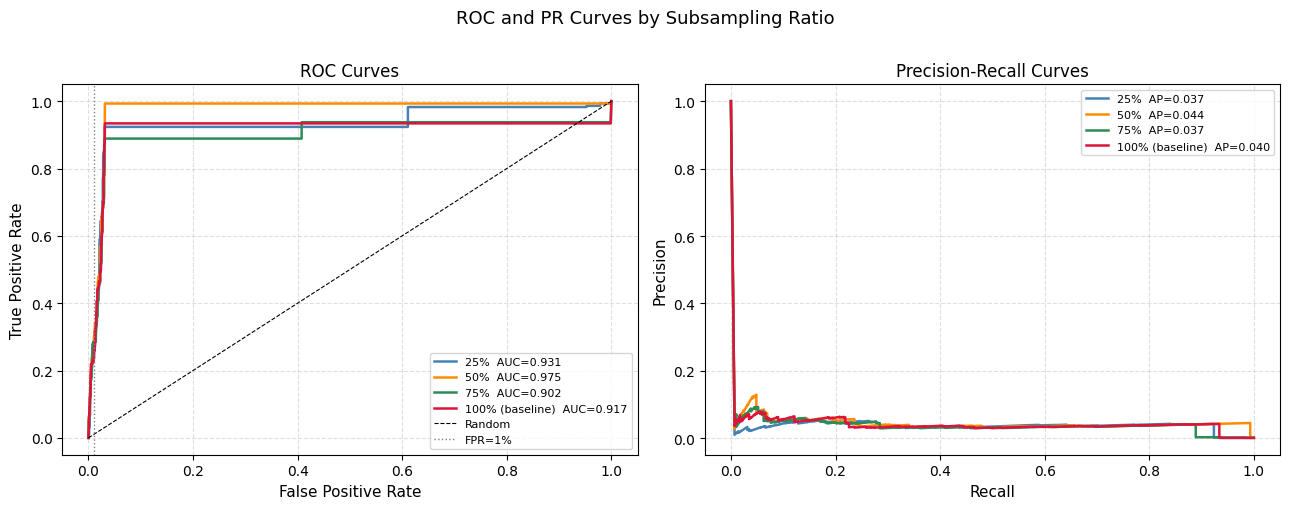

In [10]:
# ── Figure 2: ROC curves overlay + PR curves overlay ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ratio_labels = [f"{r}%" if r < 100 else "100% (baseline)" for r in RATIOS]

for m, lbl, color in zip(results, ratio_labels, COLORS):
    if not m["fpr_curve"]:
        continue
    # ROC
    axes[0].plot(m["fpr_curve"], m["tpr_curve"],
                 linewidth=1.8, color=color, label=f"{lbl}  AUC={m['auc']:.3f}")
    # PR
    axes[1].plot(m["recall_curve"], m["precision_curve"],
                 linewidth=1.8, color=color, label=f"{lbl}  AP={m['pr_auc']:.3f}")

# ROC panel
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
axes[0].axvline(0.01, color="gray", linestyle=":", linewidth=1, label="FPR=1%")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("ROC Curves", fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle="--", alpha=0.4)

# PR panel
axes[1].set_xlabel("Recall", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curves", fontsize=12)
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("ROC and PR Curves by Subsampling Ratio", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


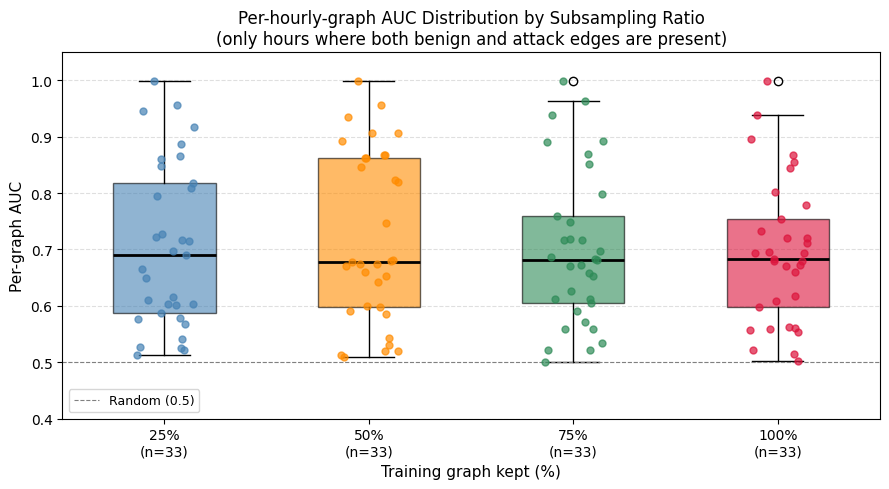


 Ratio   Mean AUC     Std     Min     Max   n graphs
--------------------------------------------------
   25%     0.7046  0.1423  0.5133  0.9993         33
   50%     0.7217  0.1483  0.5095  0.9994         33
   75%     0.6995  0.1340  0.5010  0.9996         33
  100%     0.6939  0.1247  0.5022  0.9994         33


In [11]:
# ── Figure 3: Per-graph AUC distribution (boxplot) ───────────────────────────
per_graph_data = [m["per_graph_aucs"] for m in results]
n_graphs       = [len(d) for d in per_graph_data]

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    [d if d else [np.nan] for d in per_graph_data],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    widths=0.5,
)

for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay individual points (jittered)
for i, (data_points, color) in enumerate(zip(per_graph_data, COLORS), start=1):
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(data_points))
    ax.scatter(np.full(len(data_points), i) + jitter, data_points,
               color=color, alpha=0.7, s=25, zorder=3)

ax.set_xticks(range(1, len(RATIOS) + 1))
ax.set_xticklabels([f"{r}%\n(n={n})" for r, n in zip(RATIOS, n_graphs)], fontsize=10)
ax.set_xlabel("Training graph kept (%)", fontsize=11)
ax.set_ylabel("Per-graph AUC", fontsize=11)
ax.set_title("Per-hourly-graph AUC Distribution by Subsampling Ratio\n"
             "(only hours where both benign and attack edges are present)", fontsize=12)
ax.set_ylim(0.4, 1.05)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Random (0.5)")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("per_graph_auc_boxplot.png", dpi=150)
plt.show()

# Summary statistics per ratio
print(f"\n{'Ratio':>6}  {'Mean AUC':>9}  {'Std':>6}  {'Min':>6}  {'Max':>6}  {'n graphs':>9}")
print("-" * 50)
for ratio, data_points in zip(RATIOS, per_graph_data):
    if data_points:
        print(f"{ratio:>5}%  {np.mean(data_points):>9.4f}  {np.std(data_points):>6.4f}  "
              f"{np.min(data_points):>6.4f}  {np.max(data_points):>6.4f}  {len(data_points):>9}")
    else:
        print(f"{ratio:>5}%  {'N/A':>9}")
